# Model agreement vs LLM judges on long rule sentences (R_COMP)

**Question.** You have an English sentence and a candidate first-order-logic (FOL) translation, but no gold formula. Can you tell whether the translation is faithful?

**R_COMP.** The dataset has 221 templated rule sentences. Each one has at least 25 words, at least 3 conditions, and one *unless / except / provided that / only if* clause. The references are trusted because the sentences are built from templates. Ten few-shot LLM slots from 9 model families translate every sentence. In the **SIG** condition the prompt includes the predicate signature, so all translations share one vocabulary. Each translation is labelled **CORRECT** or **ERROR** by pure z3 equivalence to the *weak* or *strong* reading of the sentence.

**Metric (`c_score_sig`, cross-family consensus).** The share of *family-disjoint* peer translations that are **not** z3-equivalent to the candidate: 0 means every other family agrees, 1 means none does. Higher means more likely an error. It needs no gold formula and no LLM.

**Full-run headline (pre-registered primary test, 1,904 SIG rows).** Within-template AUROC for `c_score_sig` is **0.954**. The disguised gemini-2.5-flash-lite rubric judge scores **0.587**. The difference is **+0.367, 95% CI [0.328, 0.404]** (sentence-clustered, template-stratified bootstrap, B = 2000), so the test **PASSES**.

**What this notebook does.** The artifact's entry point is `method.py`. It orchestrates stages S1–S11 in `src/`; the LLM-calling stages need API keys and cost money. This notebook runs, on a curated 100-row subset (10 sentences × 10 slots):
1. `method.py`'s `build()` step (S11), which turns candidate rows into `method_out.json`.
2. A recomputation of `c_score_sig` with z3, using `consensus_exact` from `src/consensus_rcomp.py` and the parser from `rcomp/labeller/fol.py`. It also re-derives the z3 labels from the weak and strong references.
3. The primary statistic (within-template AUROC delta with a clustered bootstrap), using `src/auc_tools.py` and the AUROC blocks from `src/analyse.py`.

The code is copied from the artifact with minimal changes: file paths are replaced by the loaded `data`, and the command-line arguments are removed.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT on Colab, always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (at Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports
The first block is `method.py`'s original import block. The second block adds the imports needed by the helper modules this notebook inlines (`fol.py`, `consensus_rcomp.py`, `auc_tools.py`) and by the plots.

In [2]:
# --- original method.py imports ---
from __future__ import annotations

import argparse
import json
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- extra imports for the inlined helpers (fol.py, consensus_rcomp.py, auc_tools.py) and the plots ---
import re
import signal
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import z3
import matplotlib.pyplot as plt

## Data loading
`mini_demo_data.json` holds 10 R_COMP-SIG sentences, one per template T1–T9 plus one more, chosen for label diversity. For each sentence it holds all 10 translator rows, copied unchanged from `results/rcomp_candidates.jsonl`: the candidate FOL, the z3 label, every consensus and judge score, and the complexity strata. It also holds the sentences with their weak and strong reference readings, the vendor-family map used to make peers family-disjoint, and the full-run primary result for comparison.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_e4aqYfQhdCkX/round-3/experiment-7/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(len(data["sentences"]), "sentences,", len(data["rows"]), "candidate rows")
print("label counts:", dict(Counter(r["label"] for r in data["rows"])))

10 sentences, 100 candidate rows
label counts: {'ERROR': 27, 'CORRECT': 60, 'OFF_SIGNATURE': 9, 'READING_CHOICE': 4}


## Config
These are all the tunable parameters. The original values are in the comments. The z3 timeouts are the artifact's frozen values; the demo uses the original timeouts and bootstrap size because the 100-row subset runs in seconds.

In [5]:
N_SENTENCES = 10      # sentences of the mini subset to process (max 10 here; the full run used all 221 R_COMP sentences)
B = 2000              # bootstrap replicates for the AUROC CIs (original: --B 2000)
SEED = 0              # bootstrap seed (analyse.py SEED)
Z3_MS = 5000          # z3 timeout per equivalence check, ms (original: 5000)
PAIR_CAP_S = 30       # wall-clock cap per candidate/peer pair, s (original: 30)

## `method.py`: stage list, logging, constants
This is `method.py`'s module docstring, kept verbatim as `__doc__`. It lists the resumable stages S1–S11 of the full artifact. The notebook runs S11 (`build`), plus the label-free parts of S5/S7a (z3 labels and `c_score_sig`) and S10 (the primary AUROC test) on the mini subset.

`PRED` lists the 12 predictor columns, each oriented so that higher means more likely an ERROR. `META` lists the per-row metadata fields copied into the output. The only change is that `ROOT` is the notebook's working directory rather than `Path(__file__)`.

In [6]:
__doc__ = """R_COMP: cross-family model agreement (consensus) vs LLM judges on long, heavily conditioned rule sentences.

Entry point of the artifact. The heavy stages live in src/ and run resumably (each writes to results/ or rcomp/):

  S1  rcomp/src/{lexicon,compose,select_rcomp,llm_phases}.py   dataset-3 pre-generation phases (fluency only; D1)
  S2  src/sig_prompt.py + results/prereg_sig.json(.sha256)    SIG pre-registration, git-committed before any SIG call
  S3  src/gen_sig.py pilot|full                               SIG generation (10 few-shot slots, signature block)
  S4  rcomp/src/gen_rcomp.py pilot|full                        FREE generation (dataset 3, unchanged prompt)
  S5  src/label_sig.py label|repair                           SIG labels: pure z3 equivalence to weak/strong readings
  S6  src/testability.py SIG                                  testability + label sha256, committed before any score
  S7a src/score_consensus.py run --cond SIG                    c_score_sig / c_score_align / c_score_nf / c_score_hyb / g
  S7b src/run_judges.py cheap --cond SIG                       flash-lite rubric A, disguised (the bar) + original
  S7c src/run_judges.py frontier [--pilot] --n-rows N          gemini-3.1-pro-preview on a stratified SIG subsample
  S7d src/local_judge_rcomp.py --cond SIG --orig               local Qwen3-8B judge (GPU env .venv_gpu)
  S8  rcomp/src/label_rcomp.py; src/panel_rcomp.py assemble; src/testability.py FREE   FREE solver labels (+ panel, D9)
  S9  src/score_consensus.py run --cond FREE; src/run_judges.py cheap --cond FREE
  S10 src/score_consensus.py rename; src/analyse.py; tests/audit_rederive.py
  S11 method.py build   -> method_out.json (exp_gen_sol_out) from results/rcomp_candidates.jsonl

usage: method.py stages            print the stage list above
       method.py analyse [--B N]   S10 + audit + records + S11 (CPU, $0)
       method.py build             S11 only
The reusable metric functions are in src/consensus_rcomp.py (consensus_exact, consensus_scores).
"""

ROOT = Path.cwd()  # notebook: was Path(__file__).resolve().parent
RES = ROOT / "results"
RC = ROOT / "rcomp"

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")

PRED = ["c_score_sig", "c_score_align", "c_score_nf", "c_score_hyb", "g_align", "g_nf", "judge_cheap_disg", "judge_cheap_orig",
        "judge_frontier_orig", "judge_frontier_disg", "judge_local_disg", "judge_local_orig"]
META = ["row_key", "item_id", "sentence_id", "template_id", "slot", "system", "family", "prompt_variant", "parse_ok",
        "label_source", "label_tier", "matched_reading", "off_signature", "sig_status", "repair_ops", "repair_status",
        "sig_class_id", "sig_class_id_size", "sig_class_id_n_peers", "sig_class_id_n_peers_same_class",
        "sig_class_id_peer_majority_class", "sig_class_id_is_peer_majority", "free_solver_class_id", "free_align_class_id",
        "free_hyb_class_id", "free_align_class_id_size", "free_align_class_id_is_peer_majority", "free_hyb_class_id_size",
        "free_hyb_class_id_is_peer_majority", "n_peers_sig", "n_peers_equal_sig", "n_unknown_sig", "n_peers_hyb",
        "correct_not_equivalent", "ref_flagged", "tier_B_provisional", "cost_usd", "secs_sig", "coverage_status"]


def run(cmd: list[str]) -> None:
    logger.info("$ " + " ".join(cmd))
    subprocess.run(cmd, cwd=ROOT, check=True)


def fmt_pred(v) -> str:
    return "None" if v is None else f"{float(v):.6f}"


print(__doc__)  # == `method.py stages`

R_COMP: cross-family model agreement (consensus) vs LLM judges on long, heavily conditioned rule sentences.

Entry point of the artifact. The heavy stages live in src/ and run resumably (each writes to results/ or rcomp/):

  S1  rcomp/src/{lexicon,compose,select_rcomp,llm_phases}.py   dataset-3 pre-generation phases (fluency only; D1)
  S2  src/sig_prompt.py + results/prereg_sig.json(.sha256)    SIG pre-registration, git-committed before any SIG call
  S3  src/gen_sig.py pilot|full                               SIG generation (10 few-shot slots, signature block)
  S4  rcomp/src/gen_rcomp.py pilot|full                        FREE generation (dataset 3, unchanged prompt)
  S5  src/label_sig.py label|repair                           SIG labels: pure z3 equivalence to weak/strong readings
  S6  src/testability.py SIG                                  testability + label sha256, committed before any score
  S7a src/score_consensus.py run --cond SIG                    c_score_sig / c_score_a

## Select the demo subset
This cell keeps the first `N_SENTENCES` sentences of the mini data and their 10 translator rows each. It stands in for the files `build()` originally read: `rcomp/work/rcomp_sentences.json` and `results/rcomp_candidates.jsonl`.

In [7]:
demo_sentences = data["sentences"][:N_SENTENCES]
_sids = {s["sentence_id"] for s in demo_sentences}
demo_rows = [r for r in data["rows"] if r["sentence_id"] in _sids]
print(f"{len(demo_sentences)} sentences, {len(demo_rows)} rows")
for s in demo_sentences[:2]:
    print(f"\n[{s['template_id']}, {s['clause_type']}, {s['words']} words] {s['text']}")
    print("  weak  :", s["reference_fol_weak"])
    print("  strong:", s["reference_fol_strong"])

10 sentences, 100 rows

[T1, unless, 34 words] Each game that requires the use of a spherical ball to score goals, that is preceded by data processing, and that involves two opposing teams releases heat, except if the game has a tie.
  weak  : ∀x (Game(x) ∧ RequiresSphericalBallToScoreGoals(x) ∧ PrecededBy(x, dataProcessing) ∧ InvolvesTwoOpposingTeams(x) ∧ ¬Tie(x) → ReleasesHeat(x))
  strong: ∀x (Game(x) ∧ RequiresSphericalBallToScoreGoals(x) ∧ PrecededBy(x, dataProcessing) ∧ InvolvesTwoOpposingTeams(x) → (ReleasesHeat(x) ↔ ¬Tie(x)))

[T2, except_when, 31 words] When a car is supported by legs and does not magnify distant objects, and the car also has an Apple logo, the car is heavy, except when the car is grass.
  weak  : ∀x (Car(x) ∧ SupportedByLegs(x) ∧ ¬MagnifiesDistantObjects(x) ∧ With(x, appleLogo) ∧ ¬Grass(x) → Heavy(x))
  strong: ∀x (Car(x) ∧ SupportedByLegs(x) ∧ ¬MagnifiesDistantObjects(x) ∧ With(x, appleLogo) → (Heavy(x) ↔ ¬Grass(x)))


## S11: `build()` turns candidate rows into `method_out.json`
This is `method.py`'s `build()` function. It joins each candidate row to its sentence and writes an `exp_gen_sol_out` record per row:
- `input`: the text, the candidate FOL, and the condition.
- `output`: the z3 label.
- `predict_*`: the 12 scores, each formatted by `fmt_pred`.
- `metadata_*`: the metadata fields and the complexity strata.

It then attaches the primary-test summary and the testability verdicts.

**Changes, notebook only:** the three `json.loads(Path.read_text())` reads are replaced by the loaded `data`. `A` is rebuilt from the full-run primary result shipped in the data, and the testability verdicts come from `data["testability"]`. Everything else is unchanged.

In [8]:
@logger.catch(reraise=True)
def build() -> None:
    sents = {s["sentence_id"]: s for s in demo_sentences}          # was: rcomp/work/rcomp_sentences.json
    rows = demo_rows                                               # was: results/rcomp_candidates.jsonl
    A = {"SIG": {"primary": data["full_run_primary"]}}             # was: results/analysis.json (full-run primary block)
    ds = {"SIG": [], "FREE": []}
    for r in rows:
        s = sents[r["sentence_id"]]
        ex = {"input": json.dumps({"text": s["text"], "candidate_fol": r.get("candidate_fol") or "", "condition": r["condition"]}, ensure_ascii=False),
              "output": str(r["label"])}
        for m in PRED:
            ex[f"predict_{m}"] = fmt_pred(r.get(m))
        for k in META:
            v = r.get(k)
            ex[f"metadata_{k}"] = v
        for k, v in (r.get("strata") or {}).items():
            ex[f"metadata_{k}"] = v
        ex["metadata_condition"] = r["condition"]
        ds[r["condition"]].append(ex)
    sig = A["SIG"]
    meta = {"method_name": "cross-family consensus (SIG-exact, ALIGN, NF-anchored, HYB, graded) vs LLM judges on R_COMP",
            "orientation": "every predict_* score: higher = more likely ERROR; 'None' = not computed (see metadata)",
            "labels": {"SIG": "pure z3 equivalence to the weak or strong template reading (CORRECT / ERROR / READING_CHOICE / OFF_SIGNATURE / UNPARSEABLE)",
                       "FREE": "dataset-3 solver-modulo-alignment rule, tier A only (panel not run, deviation D9): CORRECT / ERROR / UNRESOLVED / UNPARSEABLE / NO_OUTPUT"},
            "primary_test": {k: sig["primary"].get(k) for k in ("n", "n_error", "n_correct", "n_sentences", "auroc_metric", "auroc_comparator",
                                                              "delta", "ci", "p_one_sided", "PASS")},
            "testability": {"SIG": data["testability"]["SIG"],     # was: results/testability_SIG.json
                            "FREE": data["testability"].get("FREE")},  # was: results/testability_FREE.json
            "frozen_params": "exp-5 prereg scoring_params (variants ALIGN + NF-anchored, k=5, tau 0.5, timeout 2000 ms, pair cap 30 s); no tuning on R_COMP",
            "results_files": ["results/analysis.json", "results/tables.md", "results/rcomp_candidates.jsonl", "results/deviations.json"]}
    out = {"metadata": meta, "datasets": [{"dataset": "R_COMP_SIG", "examples": ds["SIG"]}]}
    if ds["FREE"]:
        out["datasets"].append({"dataset": "R_COMP_FREE", "examples": ds["FREE"]})
    (ROOT / "method_out.json").write_text(json.dumps(out, ensure_ascii=False, indent=1))
    logger.info(f"method_out.json: SIG {len(ds['SIG'])} rows, FREE {len(ds['FREE'])} rows")


build()   # == `method.py build` (main()'s argparse dispatch is dropped in the notebook)
method_out = json.loads((ROOT / "method_out.json").read_text())
ex0 = method_out["datasets"][0]["examples"][0]
print(json.dumps({k: ex0[k] for k in ["input", "output", "predict_c_score_sig", "predict_judge_cheap_disg", "metadata_slot", "metadata_family"]},
                 ensure_ascii=False, indent=1))

11:34:53|INFO   |method_out.json: SIG 100 rows, FREE 0 rows


{
 "input": "{\"text\": \"Each game that requires the use of a spherical ball to score goals, that is preceded by data processing, and that involves two opposing teams releases heat, except if the game has a tie.\", \"candidate_fol\": \"∀x ((RequiresSphericalBallToScoreGoals(x) ∧ PrecededBy(x, dataProcessing) ∧ InvolvesTwoOpposingTeams(x)) → (ReleasesHeat(x) ∧ ¬Tie(x)))\", \"condition\": \"SIG\"}",
 "output": "ERROR",
 "predict_c_score_sig": "1.000000",
 "predict_judge_cheap_disg": "1.000000",
 "metadata_slot": "G1",
 "metadata_family": "meta"
}


## The z3 layer: `rcomp/labeller/fol.py`
All labels and all `c_score_sig` values rest on this parser. It reads Unicode FOL in FOLIO/MALLS notation (`∀ ∃ ¬ ∧ ∨ → ↔ ⊕`) into an AST and translates the AST into z3 over one uninterpreted sort `U`. `equivalent(a, b)` asks z3 whether `a ↔ b` is valid, with a timeout; it returns `True`, `False`, or `None` if z3 times out.

The functions below are copied verbatim from `fol.py`. Only the ones on the equivalence path are included; the monotonicity-profile and lint helpers are left out.

In [9]:
TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|\(|\)|,|[A-Za-z_][A-Za-z0-9_'\-]*)")
OPS = {"↔": "iff", "⊕": "xor", "→": "imp", "∨": "or", "∧": "and"}
IDENT = re.compile(r"^[A-Za-z_][A-Za-z0-9_'\-]*$")
PREC = {"iff": 1, "imp": 2, "xor": 3, "or": 3, "and": 4}  # FIX (gen_art_dataset_1): ⊕ moved to the ∨ level, binds tighter than →


def tokenize(s: str) -> list[str]:
    s = s.replace("⇒", "→").replace("<->", "↔").replace("->", "→").replace("&", "∧").replace("|", "∨")  # FIX: <-> before ->
    s = s.replace("~", "¬").replace("!", "¬").replace("¬", "¬").replace("−", "-")
    pos, out = 0, []
    s = s.strip().rstrip(".")
    while pos < len(s):
        m = TOK.match(s, pos)
        if not m:
            raise ValueError(f"bad char at {pos}: {s[pos:pos+10]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


class Parser:
    def __init__(self, s: str):
        self.t = tokenize(s)
        self.i = 0

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if x is not None and tok != x:
            raise ValueError(f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self):
        e = self.expr(0)
        if self.peek() is not None:
            raise ValueError(f"trailing {self.t[self.i:]}")
        return e

    def expr(self, minp):
        lhs = self.unary()
        while self.peek() in OPS and PREC[OPS[self.peek()]] > minp - 1 and PREC[OPS[self.peek()]] >= minp:
            op = OPS[self.eat()]
            # → is right-assoc, others left-assoc
            nxt = PREC[op] if op == "imp" else PREC[op] + 1
            rhs = self.expr(nxt)
            lhs = (op, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok in ("∀", "∃"):
            self.eat()
            vs = [self.eat()]
            while self.peek() not in ("(", "¬", "∀", "∃") and self.peek() is not None and re.match(r"^[a-z][a-z0-9]*$", self.peek() or "") and not self._is_atom_start():
                vs.append(self.eat())
            body = self.unary()  # FOLIO/MALLS convention: a quantifier binds the next group/atom/quantifier
            for v in reversed(vs):
                body = ("all" if tok == "∀" else "ex", v, body)
            return body
        if tok == "(":
            self.eat("(")
            e = self.expr(0)
            self.eat(")")
            return e
        name = self.eat()
        if name is None or not IDENT.match(name):  # FIX (gen_art_dataset_1): truncated input used to yield atom None
            raise ValueError(f"expected identifier, got {name!r}")
        if self.peek() == "(":
            self.eat("(")
            args = [self.eat()]
            while self.peek() == ",":
                self.eat(",")
                args.append(self.eat())
            self.eat(")")
            if any(a is None or not IDENT.match(a) for a in args):
                raise ValueError(f"bad argument list {args!r}")
            return ("atom", name, tuple(args))
        return ("atom", name, ())  # propositional atom

    def _is_atom_start(self):
        return self.i + 1 < len(self.t) and self.t[self.i + 1] == "("


def parse(s: str):
    return Parser(s).parse()


def preds(e, acc=None):
    acc = {} if acc is None else acc
    if e[0] == "atom":
        acc[f"{e[1]}/{len(e[2])}"] = len(e[2])  # key by name/arity: arity clashes are distinct symbols
    elif e[0] in ("all", "ex"):
        preds(e[2], acc)
    elif e[0] == "not":
        preds(e[1], acc)
    else:
        preds(e[1], acc)
        preds(e[2], acc)
    return acc


U = z3.DeclareSort("U")


def to_z3(e, env, P):
    k = e[0]
    if k in ("all", "ex"):
        v = z3.Const(e[1], U)
        env2 = dict(env)
        env2[e[1]] = v
        b = to_z3(e[2], env2, P)
        return z3.ForAll([v], b) if k == "all" else z3.Exists([v], b)
    if k == "not":
        return z3.Not(to_z3(e[1], env, P))
    if k == "atom":
        args = [env.get(a, z3.Const("c_" + a, U)) for a in e[2]]
        f = P[f"{e[1]}/{len(e[2])}"]
        return f(*args) if args else f
    a, b = to_z3(e[1], env, P), to_z3(e[2], env, P)
    return {"and": lambda: z3.And(a, b), "or": lambda: z3.Or(a, b), "imp": lambda: z3.Implies(a, b),
            "iff": lambda: a == b, "xor": lambda: z3.Xor(a, b)}[k]()


def mkpred(name, n):
    name = name.replace("/", "_a")
    return z3.Function(name, *([U] * n), z3.BoolSort()) if n else z3.Bool(name)


def valid(c, ms=3000):
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(z3.Not(c))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


def equivalent(e1, e2, ms=5000):
    ar = {**preds(e1), **preds(e2)}
    P = {q: mkpred(q, m) for q, m in ar.items()}
    return valid(to_z3(e1, {}, P) == to_z3(e2, {}, P), ms)

### Re-derive the SIG labels (the pure-z3 rule of stage S5)
A SIG candidate is **CORRECT** if z3 proves it equivalent to the weak *or* the strong reading of its sentence, and **ERROR** otherwise. The shipped labels also include OFF_SIGNATURE (a predicate outside the given signature), READING_CHOICE, and UNPARSEABLE; those come from `label_sig.py`'s signature checks and are not re-derived here. This cell recomputes the rule for every parseable CORRECT/ERROR row and checks it against the shipped label.

In [10]:
S = {s["sentence_id"]: s for s in demo_sentences}
lab_rows = []
for r in demo_rows:
    if r["label"] not in ("CORRECT", "ERROR"):
        continue
    s = S[r["sentence_id"]]
    c = parse(r["candidate_fol"])
    w = equivalent(c, parse(s["reference_fol_weak"]), Z3_MS)
    st = equivalent(c, parse(s["reference_fol_strong"]), Z3_MS)
    rederived = "CORRECT" if (w is True or st is True) else "ERROR"
    lab_rows.append({"slot": r["slot"], "template": r["template_id"], "label": r["label"], "rederived": rederived,
                     "eq_weak": w, "eq_strong": st, "matched_reading": r["matched_reading"]})
lab_df = pd.DataFrame(lab_rows)
print(f"re-derived z3 label == shipped label on {(lab_df.label == lab_df.rederived).sum()}/{len(lab_df)} rows")
print(pd.crosstab(lab_df.label, [lab_df.eq_weak, lab_df.eq_strong], rownames=["label"], colnames=["≡weak", "≡strong"]))

re-derived z3 label == shipped label on 87/87 rows
≡weak   False       True 
≡strong False True  False
label                    
CORRECT     0    14    46
ERROR      27     0     0


## The metric: `consensus_exact` (from `src/consensus_rcomp.py`)
Given a candidate formula and the translations of the **same sentence** by **other** model families, the function returns the share of peers that are **not** z3-equivalent to the candidate under identical predicate names. A peer that fails to parse or times out counts as disagreeing. It is valid only when all translations share one signature, as in SIG: renaming a predicate makes a correct formula disagree with everyone.

`_equiv` and `consensus_exact` are copied verbatim. The one change is that `from fol import ...` now refers to the functions defined above.

In [11]:
class _Timeout(Exception):
    pass


def _alarm(signum, frame):  # noqa: ARG001
    raise _Timeout()


def _equiv(a, b, ms: int, cap_s: int):
    # notebook: `from fol import equivalent` -> uses the equivalent() defined above
    old = signal.signal(signal.SIGALRM, _alarm)
    signal.alarm(cap_s)
    try:
        return equivalent(a, b, ms)
    except _Timeout:
        return None
    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, old)


def consensus_exact(fol: str, peers: list[str], ms: int = 5000, pair_cap_s: int = 30, return_details: bool = False):
    """Share of family-disjoint peers NOT z3-equivalent to `fol` under identical vocabulary (see module docstring).

    fol   : candidate formula (dataset-E FOL syntax: ∀ ∃ ¬ ∧ ∨ → ↔, Pred(x, const)).
    peers : translations of the same sentence by OTHER model families (the caller enforces family-disjointness).
    Returns a float in [0, 1] (None if the candidate is unparseable or fewer than 2 peers), or a dict with details.
    """
    # notebook: `from fol import parse` -> uses the parse() defined above
    try:
        c = parse(fol)
    except Exception:  # noqa: BLE001 - the parser raises assorted errors on junk
        return {"score": None, "reason": "unparseable"} if return_details else None
    if len(peers) < 2:
        return {"score": None, "reason": "fewer than 2 peers"} if return_details else None
    eqs = []
    for p in peers:
        try:
            pe = parse(p)
        except Exception:  # noqa: BLE001
            eqs.append(False)
            continue
        eqs.append(True if str(pe) == str(c) else _equiv(c, pe, ms, pair_cap_s))
    score = 1 - sum(e is True for e in eqs) / len(eqs)
    if return_details:
        return {"score": score, "n_peers": len(eqs), "n_equal": sum(e is True for e in eqs), "n_unknown": sum(e is None for e in eqs)}
    return score

### Recompute `c_score_sig` for every candidate (stage S7a)
Peers follow `score_consensus.py`: the parseable few-shot rows of the same sentence whose **vendor family** (from `family_map_vendor`) differs from the candidate's. So G1 and G1b (both Meta) never vote for each other, and neither do G5 and G8 (both Google). The recomputed score is compared with the `c_score_sig` shipped in the data. The artifact gives off-signature and unparseable candidates no score (`None`), so those rows are skipped.

In [12]:
fam = data["family_map_vendor"]
t0 = time.time()
cons_rows = []
for sid in S:
    rows_s = [r for r in demo_rows if r["sentence_id"] == sid]
    for r in rows_s:
        peers = [p["candidate_fol"] for p in rows_s if p["parse_ok"] and fam[p["slot"]] != fam[r["slot"]]]
        d = consensus_exact(r["candidate_fol"] or "", peers, ms=Z3_MS, pair_cap_s=PAIR_CAP_S, return_details=True)
        cons_rows.append({"sentence_id": sid, "template_id": r["template_id"], "slot": r["slot"], "label": r["label"],
                          "c_score_sig_shipped": r["c_score_sig"], "c_score_sig_recomputed": d["score"],
                          "n_peers": d.get("n_peers"), "n_equal": d.get("n_equal"), "n_unknown": d.get("n_unknown")})
cons_df = pd.DataFrame(cons_rows)
secs = time.time() - t0
both = cons_df.dropna(subset=["c_score_sig_shipped", "c_score_sig_recomputed"])
n_match = int((np.abs(both.c_score_sig_shipped - both.c_score_sig_recomputed) < 1e-9).sum())
print(f"{len(cons_df)} candidates scored in {secs:.1f}s; recomputed == shipped c_score_sig on {n_match}/{len(both)} scored rows")
print(cons_df.groupby("label")["c_score_sig_recomputed"].describe()[["count", "mean", "min", "max"]])

100 candidates scored in 1.7s; recomputed == shipped c_score_sig on 91/91 scored rows
                count      mean       min  max
label                                         
CORRECT          60.0  0.444907  0.125000  1.0
ERROR            27.0  0.972737  0.875000  1.0
OFF_SIGNATURE     9.0  1.000000  1.000000  1.0
READING_CHOICE    4.0  0.833333  0.777778  1.0


## S10: the primary statistic, within-template AUROC with a clustered bootstrap
`StratAUC`, `boot_weights`, and `summarize` come from `src/auc_tools.py`. `Ctx`, `_arrays`, `auc_obj`, `counts`, and `delta_block` come from `src/analyse.py`. All are copied verbatim.

The AUROC is computed **within each template** and pooled as Σ U_s / Σ P_s, where U_s counts ERROR×CORRECT pairs in which the ERROR row scores higher (ties count 0.5) and P_s is the number of such pairs. This stops template difficulty from inflating the score. For the bootstrap, sentences are resampled with replacement within their template. The same weights are shared across all metrics, so the AUROC differences are paired.

In [13]:
# ---- src/auc_tools.py ----
class StratAUC:
    """Precomputes per-stratum score ranks once; value(cluster_weights) is then O(n) per replicate."""

    def __init__(self, score: np.ndarray, is_err: np.ndarray, stratum: np.ndarray, cluster: np.ndarray,
                 stratum_is_cluster: bool = False):
        score = np.asarray(score, dtype=float)
        is_err = np.asarray(is_err, dtype=bool)
        self.linear = stratum_is_cluster
        self.parts = []
        for s in np.unique(stratum):
            m = stratum == s
            y = is_err[m]
            if y.all() or (~y).all():
                continue
            u, g = np.unique(score[m], return_inverse=True)
            self.parts.append((g.astype(np.int64), y, cluster[m], len(u)))

    def value(self, cw: np.ndarray | None = None) -> float:
        U = P = 0.0
        for g, y, cl, ng in self.parts:
            if cw is None:
                w = np.ones(len(g))
            else:
                w = cw[cl].astype(float)
                if self.linear:
                    w = np.sqrt(w)
            negw = np.bincount(g[~y], w[~y], minlength=ng)
            posw = np.bincount(g[y], w[y], minlength=ng)
            below = np.cumsum(negw) - negw
            U += float((posw * (below + 0.5 * negw)).sum())
            P += float(posw.sum() * negw.sum())
        return U / P if P > 0 else float("nan")

    def n_pairs(self) -> int:
        return int(sum(int(y.sum()) * int((~y).sum()) for _, y, _, _ in self.parts))


def boot_weights(cluster_stratum: np.ndarray, B: int, seed: int) -> np.ndarray:
    """(B, n_clusters) integer multiplicities; clusters resampled with replacement within their stratum (template)."""
    rng = np.random.default_rng(seed)
    n = len(cluster_stratum)
    W = np.zeros((B, n), dtype=np.int32)
    groups = [np.flatnonzero(cluster_stratum == s) for s in np.unique(cluster_stratum)]
    for b in range(B):
        for idx in groups:
            draw = rng.choice(idx, size=len(idx), replace=True)
            np.add.at(W[b], draw, 1)
    return W


def summarize(point: float, boots: np.ndarray) -> dict:
    boots = boots[~np.isnan(boots)]
    if len(boots) == 0:
        return {"est": point, "ci": [None, None], "se": None, "n_boot": 0}
    return {"est": point, "ci": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))],
            "se": float(np.std(boots, ddof=1)), "n_boot": int(len(boots))}


# ---- src/analyse.py (AUROC blocks) ----
class Ctx:
    """Per condition: sentence index + ONE set of bootstrap weights (paired across every metric and comparison)."""

    def __init__(self, rows: list[dict], B: int):
        sids = sorted({r["sentence_id"] for r in rows})
        self.sidx = {s: i for i, s in enumerate(sids)}
        tm = {r["sentence_id"]: r["template_id"] for r in rows}
        self.W = boot_weights(np.array([tm[s] for s in sids]), B, SEED)
        self.B = B


def _arrays(ctx: Ctx, rows: list[dict], key: str, stratum: str):
    s = np.array([r[key] for r in rows], dtype=float)
    y = np.array([r["label"] == "ERROR" for r in rows])
    cl = np.array([ctx.sidx[r["sentence_id"]] for r in rows])
    if stratum == "template":
        st = np.array([r["template_id"] for r in rows])
    elif stratum == "sentence":
        st = cl.copy()
    elif stratum == "pooled":
        st = np.zeros(len(rows), dtype=int)
    else:
        st = np.array([r["strata"][stratum] for r in rows])
    return s, y, st, cl


def auc_obj(ctx: Ctx, rows: list[dict], key: str, stratum: str) -> StratAUC:
    s, y, st, cl = _arrays(ctx, rows, key, stratum)
    return StratAUC(s, y, st, cl, stratum_is_cluster=(stratum == "sentence"))


def counts(rows: list[dict]) -> dict:
    return {"n": len(rows), "n_error": sum(r["label"] == "ERROR" for r in rows), "n_correct": sum(r["label"] == "CORRECT" for r in rows),
            "n_sentences": len({r["sentence_id"] for r in rows})}


def delta_block(ctx: Ctx, rows: list[dict], k1: str, k2: str, stratum: str = "template") -> dict:
    rows = [r for r in rows if r.get(k1) is not None and r.get(k2) is not None]
    c = counts(rows)
    if c["n_error"] == 0 or c["n_correct"] == 0:
        return {**c, "untestable": True}
    a1, a2 = auc_obj(ctx, rows, k1, stratum), auc_obj(ctx, rows, k2, stratum)
    p1, p2 = a1.value(), a2.value()
    b1 = np.array([a1.value(ctx.W[b]) for b in range(ctx.B)])
    b2 = np.array([a2.value(ctx.W[b]) for b in range(ctx.B)])
    d = b1 - b2
    ok = ~np.isnan(d)
    sm = summarize(p1 - p2, d)
    return {**c, "metric": k1, "comparator": k2, "stratum": stratum, "auroc_metric": p1, "auroc_comparator": p2,
            "auroc_metric_ci": summarize(p1, b1)["ci"], "auroc_comparator_ci": summarize(p2, b2)["ci"],
            "delta": p1 - p2, "ci": sm["ci"], "se": sm["se"], "p_one_sided": float(np.mean(d[ok] <= 0)) if ok.any() else None,
            "ci_lower_gt_0": bool(sm["ci"][0] is not None and sm["ci"][0] > 0)}

### Run the primary test on the demo subset
The primary set is the SIG rows labelled CORRECT or ERROR. The test compares `c_score_sig` with the disguised cheap judge `judge_cheap_disg`; the secondary comparison is against the original-text judge. The pre-registered criterion is **PASS if the 95% CI lower bound of the delta is above 0**.

The full run had 1,904 rows and 220 sentences. With only 10 sentences here, the CIs are much wider, and the template-stratified bootstrap has almost nothing to resample: most templates contribute a single sentence.

In [14]:
prim_rows = [r for r in demo_rows if r["label"] in ("CORRECT", "ERROR")]
ctx = Ctx(prim_rows, B)
t0 = time.time()
prim = delta_block(ctx, prim_rows, "c_score_sig", "judge_cheap_disg")
prim["PASS"] = prim.get("ci_lower_gt_0", False)
sec = delta_block(ctx, prim_rows, "c_score_sig", "judge_cheap_orig")
print(f"bootstrap B={B}: {time.time() - t0:.1f}s")

cmp = pd.DataFrame({
    "demo subset": {k: prim.get(k) for k in ["n", "n_error", "n_correct", "n_sentences", "auroc_metric", "auroc_comparator", "delta", "ci", "PASS"]},
    "full run (artifact)": {k: data["full_run_primary"].get(k) for k in ["n", "n_error", "n_correct", "n_sentences", "auroc_metric", "auroc_comparator", "delta", "ci", "PASS"]},
})
print("PRIMARY: c_score_sig vs judge_cheap_disg (within-template AUROC)")
print(cmp.to_string())
print(f"\nSECONDARY vs original-text judge: delta {sec['delta']:+.3f}  CI {np.round(sec['ci'], 3).tolist()}   (full run: +0.278 [0.239, 0.319])")

bootstrap B=2000: 0.7s
PRIMARY: c_score_sig vs judge_cheap_disg (within-template AUROC)
                                                demo subset                         full run (artifact)
n                                                        87                                        1904
n_error                                                  27                                         395
n_correct                                                60                                        1509
n_sentences                                              10                                         220
auroc_metric                                       0.964912                                     0.95434
auroc_comparator                                   0.561404                                    0.587218
delta                                              0.403509                                    0.367122
ci                [0.40052356020942403, 0.4139072847682119]  [0.3284245273241157

## Results: every predictor on the demo subset
The table gives the within-template AUROC of each of the 12 `PRED` columns on the rows where that column has a score, with bootstrap CIs. The frontier judge was run on only a 60-row subsample in the full study, so here it is mostly `None`. The figures show:
1. AUROC per predictor.
2. The distribution of `c_score_sig` for CORRECT vs ERROR rows.
3. The consensus score against the disguised judge score for each row.

          predictor  n  auroc  ci_lo  ci_hi
        c_score_sig 87  0.965  0.960  0.969
      c_score_align 87  0.965  0.960  0.969
         c_score_nf 87  0.965  0.960  0.969
        c_score_hyb 87  0.965  0.960  0.969
            g_align 87  1.000  1.000  1.000
               g_nf 87  1.000  1.000  1.000
   judge_cheap_disg 87  0.561  0.546  0.568
   judge_cheap_orig 84  0.604  0.596  0.615
judge_frontier_orig  3    NaN    NaN    NaN
judge_frontier_disg  3    NaN    NaN    NaN
   judge_local_disg 87  0.526  0.497  0.550
   judge_local_orig 87  0.731  0.672  0.783


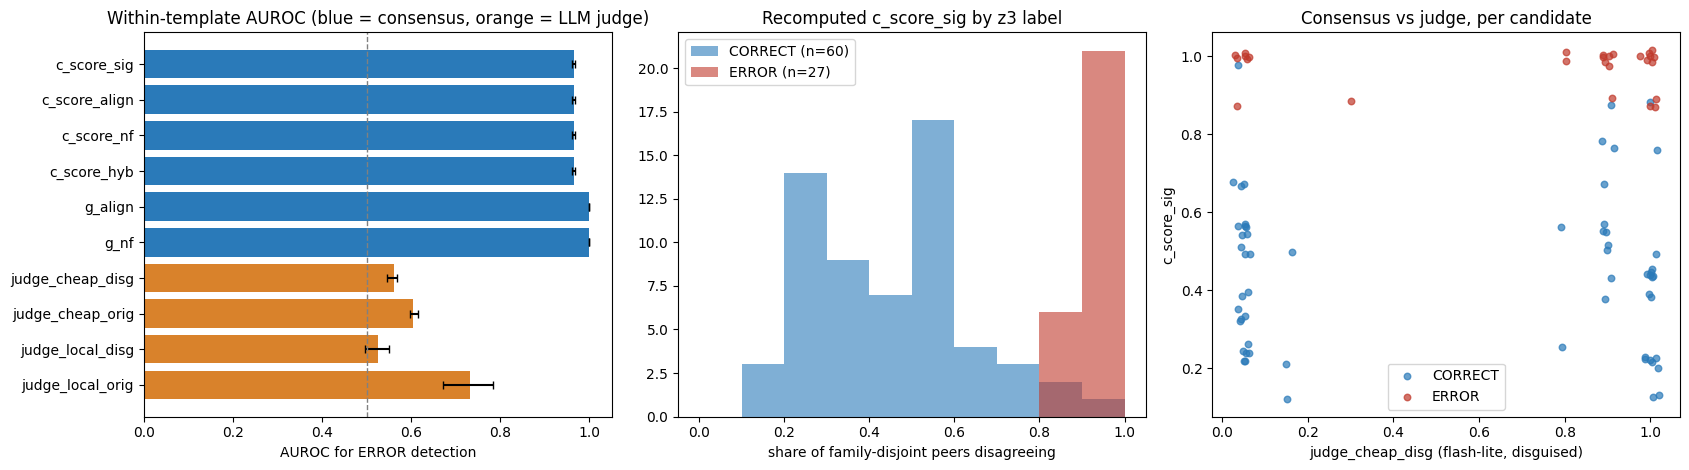


Per-sentence view (label counts and mean scores):
                          n_error  n_correct  mean_c_sig_err  mean_c_sig_cor
template_id sentence_id                                                     
T1          0204779a7f56        1          8           1.000           0.217
T2          29e0cb67f12f        4          5           0.938           0.733
T3          3e4cf1dde260        2          7           1.000           0.333
T4          8b93c01e2858        3          6           1.000           0.451
T5          07f72541bd20        4          5           1.000           0.544
T6          226923c83893        3          6           0.917           0.421
T7          04d0f8fd3c5a        5          5           0.953           0.817
T8          02f7bb8e913c        1          5           1.000           0.533
            0478ee92b867        3          5           1.000           0.533
T9          0318564696af        1          8           1.000           0.198


In [15]:
res = []
for k in PRED:
    rk = [r for r in prim_rows if r.get(k) is not None]
    c = counts(rk)
    if c["n_error"] == 0 or c["n_correct"] == 0:
        res.append({"predictor": k, "n": c["n"], "auroc": np.nan, "ci_lo": np.nan, "ci_hi": np.nan})
        continue
    ctx_k = Ctx(rk, B)
    a = auc_obj(ctx_k, rk, k, "template")
    bs = np.array([a.value(ctx_k.W[b]) for b in range(ctx_k.B)])
    sm = summarize(a.value(), bs)
    res.append({"predictor": k, "n": c["n"], "auroc": sm["est"], "ci_lo": sm["ci"][0], "ci_hi": sm["ci"][1]})
res_df = pd.DataFrame(res)
print(res_df.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
ok = res_df.dropna(subset=["auroc"])
colors = ["#2a7ab9" if p.startswith(("c_", "g_")) else "#d9822b" for p in ok.predictor]
err = np.vstack([ok.auroc - ok.ci_lo, ok.ci_hi - ok.auroc]).clip(min=0)
axes[0].barh(ok.predictor, ok.auroc, xerr=err, color=colors, capsize=3)
axes[0].axvline(0.5, color="grey", ls="--", lw=1)
axes[0].set_xlim(0, 1.05); axes[0].invert_yaxis()
axes[0].set_title("Within-template AUROC (blue = consensus, orange = LLM judge)")
axes[0].set_xlabel("AUROC for ERROR detection")

for lab, col in [("CORRECT", "#2a7ab9"), ("ERROR", "#c0392b")]:
    v = cons_df.loc[cons_df.label == lab, "c_score_sig_recomputed"].dropna()
    axes[1].hist(v, bins=np.linspace(0, 1, 11), alpha=0.6, color=col, label=f"{lab} (n={len(v)})")
axes[1].set_title("Recomputed c_score_sig by z3 label"); axes[1].set_xlabel("share of family-disjoint peers disagreeing")
axes[1].legend()

pr = pd.DataFrame(prim_rows)
rng = np.random.default_rng(0)
for lab, col in [("CORRECT", "#2a7ab9"), ("ERROR", "#c0392b")]:
    m = pr.label == lab
    axes[2].scatter(pr.loc[m, "judge_cheap_disg"] + rng.normal(0, .01, m.sum()), pr.loc[m, "c_score_sig"] + rng.normal(0, .01, m.sum()),
                    s=22, alpha=0.7, color=col, label=lab)
axes[2].set_xlabel("judge_cheap_disg (flash-lite, disguised)"); axes[2].set_ylabel("c_score_sig")
axes[2].set_title("Consensus vs judge, per candidate"); axes[2].legend()
plt.tight_layout(); plt.show()

print("\nPer-sentence view (label counts and mean scores):")
per_s = pr.groupby(["template_id", "sentence_id"]).agg(n_error=("label", lambda x: (x == "ERROR").sum()), n_correct=("label", lambda x: (x == "CORRECT").sum()),
                                                       mean_c_sig_err=("c_score_sig", lambda x: x[pr.loc[x.index, "label"] == "ERROR"].mean()),
                                                       mean_c_sig_cor=("c_score_sig", lambda x: x[pr.loc[x.index, "label"] == "CORRECT"].mean()))
print(per_s.round(3).to_string())

**Reading the results.** On the demo subset, as in the full run, cross-family agreement under a shared signature separates ERROR from CORRECT translations much better than a cheap LLM judge. A wrong translation is rarely matched by other families, so its `c_score_sig` is high. Correct translations mostly share one z3 equivalence class. The artifact finds that the remaining consensus false alarms are mostly correct translations of the minority *strong* reading.

Caveats from the artifact:
- `c_score_sig` depends on the SIG setting. It is **not** rename-invariant (false-alarm rate 1.0 under nonce renames).
- The deployable name-free variants (NF-anchored, HYB) are invariant, but on the FREE condition their AUROC drops to about 0.80.
- The FREE condition is NOT_TESTABLE because the dataset-E panel was not run.